# 01 — Explore NVDA M1

Load minute bars from `data_lake_m1`, check coverage (RTH), and plot price/volume.
Kernel: **Algo Trading (quant_sandbox)**.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from quant_sandbox import load_bars

SYMBOL = "NVDA"
START = "2024-05-01"
LAKE = "data_lake_m1"  # M1 only — do not mix with data_lake (H1)

df = load_bars(SYMBOL, start=START, lake_root=LAKE)
print(f"{SYMBOL} M1: {len(df):,} bars")
print(f"range: {df.index.min()} → {df.index.max()}")

NVDA M1: 200,231 bars
range: 2024-05-01 09:30:00+00:00 → 2026-05-22 10:40:00+00:00


In [2]:
df.describe()

,open,high,low,close,volume
count,200231.000000,200231.000000,200231.000000,200231.000000,2.002310e+05
mean,150.915269,151.025189,150.800168,150.915117,4.259638e+05
std,33.305784,33.308931,33.303936,33.305523,4.195937e+05
min,81.290000,81.400000,81.250000,81.290000,3.528800e+04
25%,122.450000,122.550000,122.325000,122.450000,1.954265e+05
50%,142.650000,142.750000,142.560000,142.660000,3.071910e+05
75%,181.550000,181.650000,181.440000,181.550000,5.100660e+05
max,236.470000,236.540000,236.360000,236.450000,1.950042e+07


In [3]:
bars_per_day = df.groupby(df.index.date).size().rename("bars")
print("Bars per session day (RTH ≈ 390 for 1-min US stocks):")
print(bars_per_day.describe().astype(int))
print("\nDays with unusually few bars (< 300):")
print(bars_per_day[bars_per_day < 300].head(10))

Bars per session day (RTH ≈ 390 for 1-min US stocks):
count    517
mean     387
std       23
min       71
25%      390
50%      390
75%      390
max      390
Name: bars, dtype: int64

Days with unusually few bars (< 300):
2024-07-03    210
2024-11-29    210
2024-12-24    210
2025-07-03    210
2025-11-28    210
2025-12-24    210
2026-05-22     71
Name: bars, dtype: int64


In [12]:
monthly = (
    df.assign(year=df.index.year, month=df.index.month)
    .groupby(["year", "month"], as_index=False)
    .size()
    .rename(columns={"size": "bars"})
)
monthly["label"] = monthly.apply(lambda r: f"{int(r['year'])}-{int(r['month']):02d}", axis=1)
monthly

,year,month,bars,label
0,2024,5,8580,2024-05
1,2024,6,7410,2024-06
2,2024,7,8400,2024-07
3,2024,8,8580,2024-08
4,2024,9,7800,2024-09
5,2024,10,8970,2024-10
6,2024,11,7620,2024-11
7,2024,12,8010,2024-12
8,2025,1,7800,2025-01
9,2025,2,7410,2025-02


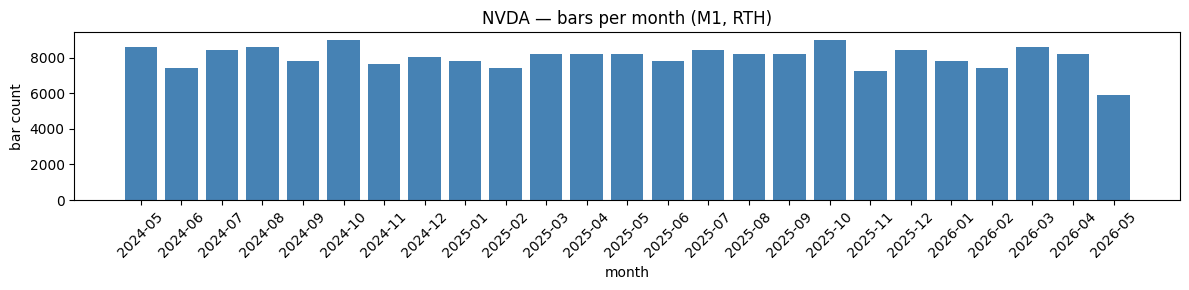

In [13]:
fig, ax = plt.subplots(figsize=(12, 3))
ax.bar(monthly["label"], monthly["bars"], color="steelblue")
ax.set_title(f"{SYMBOL} — bars per month (M1, RTH)")
ax.set_xlabel("month")
ax.set_ylabel("bar count")
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()

In [17]:
# One full session: minute grid vs actual bars (gaps = missing minutes)
SESSION_DAY = "2024-05-01"
day = df.loc[SESSION_DAY:SESSION_DAY]

expected = pd.date_range(day.index.min(), day.index.max(), freq="1min", tz="UTC")
missing = expected.difference(day.index)

print(f"session {SESSION_DAY}: {len(day)} bars, {len(missing)} missing minutes in range")
if len(missing) > 0:
    print("first gaps:", missing[:5].tolist())

session 2024-05-01: 390 bars, 0 missing minutes in range


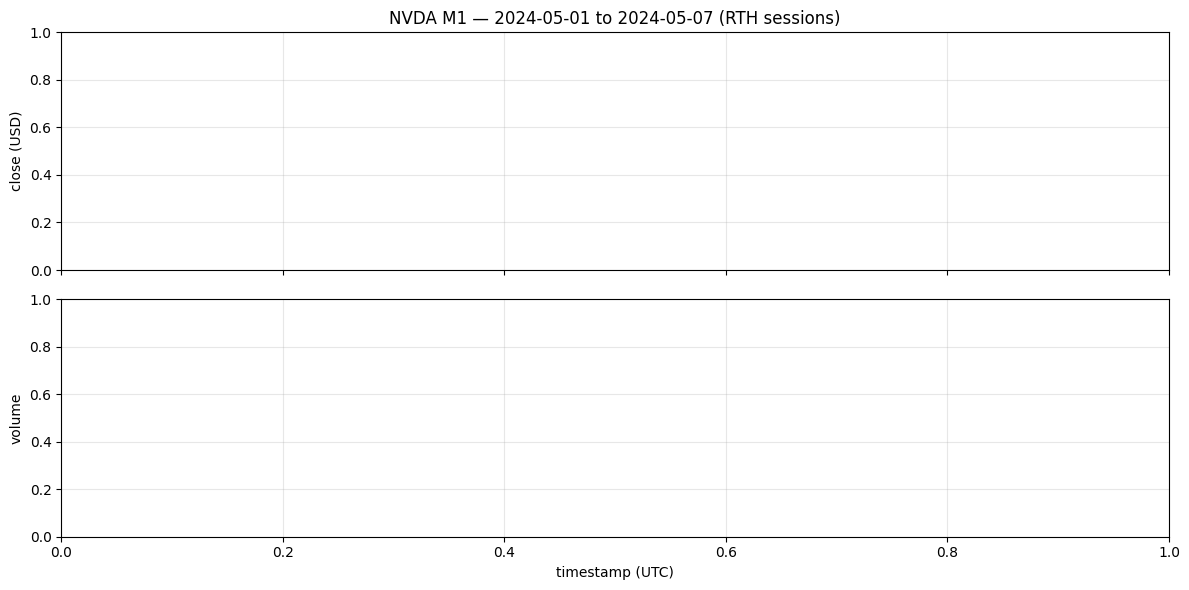

In [18]:
# Close + volume for one week (readable on screen)
PLOT_START = "2024-05-01"
PLOT_END = "2024-05-07"
sample = df.loc[PLOT_START:PLOT_END]


def plot_rth_sessions(ax, frame, column, **plot_kwargs):
    """Plot each trading day separately so overnight gaps stay empty."""
    for _, day in frame.groupby(frame.index.normalize()):
        ax.plot(day.index, day[column], **plot_kwargs)


fig, (ax_price, ax_vol) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
plot_rth_sessions(ax_price, sample, "close", linewidth=0.8)
ax_price.set_ylabel("close (USD)")
ax_price.set_title(f"{SYMBOL} M1 — {PLOT_START} to {PLOT_END} (RTH sessions)")
ax_price.grid(True, alpha=0.3)

plot_rth_sessions(ax_vol, sample, "volume", color="tab:orange", linewidth=0.8)
ax_vol.set_ylabel("volume")
ax_vol.set_xlabel("timestamp (UTC)")
ax_vol.grid(True, alpha=0.3)
fig.tight_layout()